Scenario: Vaccination Planning by Region

We have regional data:

Population density
Average income
Vaccine uptake (%)
Distance to nearest clinic
Elderly population (%)

👉 Goal: Find groups of regions and decide where  need  interventions

Step 1: Create Toy Public Health Data

In [5]:
import pandas as pd

data = {
    'Region': ['A','B','C','D','E','F','G','H'],
    'Population_Density': [100, 300, 500, 50, 80, 450, 600, 70],
    'Income': [30000, 50000, 70000, 25000, 28000, 65000, 80000, 27000],
    'Vaccine_Uptake': [60, 70, 85, 50, 55, 80, 90, 52],
    'Distance_to_Clinic': [20, 10, 5, 30, 25, 8, 3, 28],
    'Elderly_%': [20, 15, 10, 30, 25, 12, 8, 28]
}

df = pd.DataFrame(data)
df

,Region,Population_Density,Income,Vaccine_Uptake,Distance_to_Clinic,Elderly_%
0,A,100,30000,60,20,20
1,B,300,50000,70,10,15
2,C,500,70000,85,5,10
3,D,50,25000,50,30,30
4,E,80,28000,55,25,25
5,F,450,65000,80,8,12
6,G,600,80000,90,3,8
7,H,70,27000,52,28,28


✅ What this does:

Creates region-level health + access data

🎯 Why:

This mimics real public health datasets

Step 2: Scale the Data

In [6]:
from sklearn.preprocessing import StandardScaler

features = df.drop(columns=['Region'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

Step 3: Apply PCA (Dimensionality Reduction)

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

What this does:

Reduces 5 variables → 2 main components

🎯 Why:

Simplifies data while keeping patterns

🔍 Interpretation:
Component 1 → “Access + Wealth”
Component 2 → “Risk + Vulnerability”

👉 This is the hidden structure

Step 4: Cluster Regions

In [8]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(pca_data)

df['Cluster'] = clusters
df

,Region,Population_Density,Income,Vaccine_Uptake,Distance_to_Clinic,Elderly_%,Cluster
0,A,100,30000,60,20,20,1
1,B,300,50000,70,10,15,2
2,C,500,70000,85,5,10,0
3,D,50,25000,50,30,30,1
4,E,80,28000,55,25,25,1
5,F,450,65000,80,8,12,0
6,G,600,80000,90,3,8,0
7,H,70,27000,52,28,28,1


Group region to Clusters


Step 5: Visualize Clusters

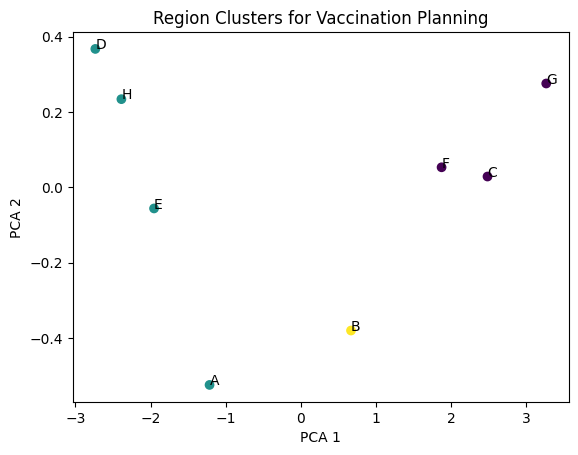

In [9]:
import matplotlib.pyplot as plt

plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters)
for i, txt in enumerate(df['Region']):
    plt.annotate(txt, (pca_data[i,0], pca_data[i,1]))

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Region Clusters for Vaccination Planning")
plt.show()

Now the IMPORTANT part → Interpretation

Let’s say clustering gives:

🟢 Cluster 0 → Urban, High Uptake
High income
Close to clinics
High vaccination

👉 ✅ Action:

Maintain current strategy
Use for benchmarking

Cluster 1 → Rural, Low Access
Low income
Far from clinics
Low vaccination

👉 🚨 Action:

Mobile clinics
Transportation support
Community outreach

In [ ]:
🔴 Cluster 2 → Moderate Access but Hesitancy
Medium distance
Medium income
Lower uptake than expected

👉 ⚠️ Action:

Awareness campaigns
Address vaccine hesitancy
Partner with local leaders

Why PCA + Clustering Together?
PCA:
Reduces noise
Combines correlated features
Clustering:
Finds groups

👉 Together:

Cleaner + more meaningful clusters

FINAL INSIGHT (What Public Health Teams Actually Do)

This pipeline:

Collect messy data
Clean + scale
Reduce complexity (PCA)
Cluster regions
Translate clusters → real interventions

BIG TAKEAWAY

👉 Clustering is not the goal
👉 Decision-making is the goal

Data → Patterns → Clusters → Actions → Better Health Outcomes